--- Standardized Dataset Columns ---
['name', 'age', 'salary', 'join_date', 'department']

--- Raw Dataset Upload Preview ---
    name   age   salary  join_date department
0    Pam  25.0  70200.0  1/15/2023         HR
1   Jane   NaN  65000.0   8/1/2022    Finance
2  Alice  22.0  71350.0  5/20/2021         HR
3    Bob  22.0      NaN  1/15/2023         IT
4    Pam  25.0  71250.0  1/15/2023         HR

Success! Cleaned file generated as 'cleaned_data.csv' in your files panel.


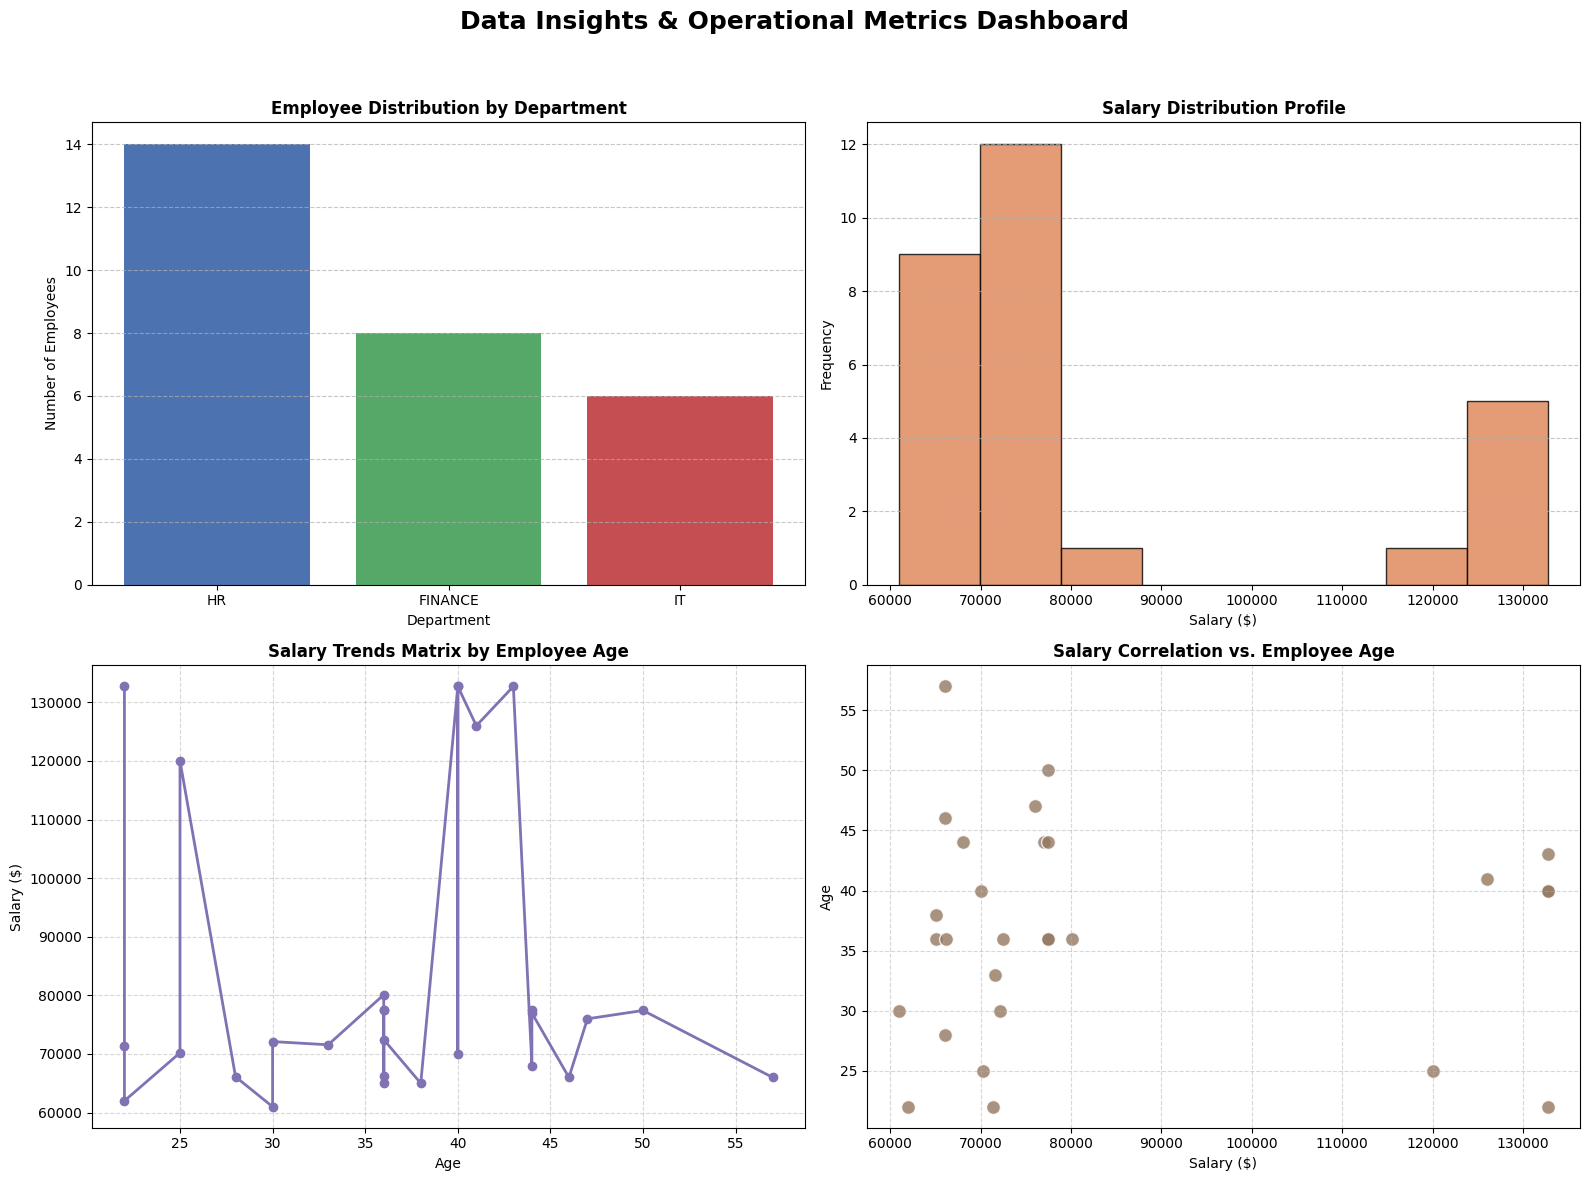

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PART 1: DATA CLEANING & PREPROCESSING
# ==========================================

# Step 1: Load the uploaded CSV file from your environment sidebar
file_name = 'sample_data_cleaning_project.csv'
data = pd.read_csv(file_name)

# CRITICAL FIX: Force all column names to lowercase to prevent missing variable errors
data.columns = data.columns.str.strip().str.lower()

print("--- Standardized Dataset Columns ---")
print(data.columns.tolist())
print("\n--- Raw Dataset Upload Preview ---")
print(data.head())

# Step 2: Impute Missing Data Values [08:22]
if 'age' in data.columns:
    data['age'] = pd.to_numeric(data['age'], errors='coerce')
    data['age'] = data['age'].fillna(data['age'].median())

if 'salary' in data.columns:
    data['salary'] = pd.to_numeric(data['salary'], errors='coerce')
    data['salary'] = data['salary'].fillna(data['salary'].mean())

if 'join_date' in data.columns:
    data = data.dropna(subset=['join_date'])

# Step 3: Text Field Standardization & Casing Cleanups [12:28, 12:57]
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype(str).str.strip().str.lower()

# Step 4: Delete Duplicate Rows [14:21]
if 'name' in data.columns:
    data = data.drop_duplicates(subset=['name'])

# Step 5: Statistical Outlier Elimination (IQR Method on Salary) [17:02]
if 'salary' in data.columns:
    Q1 = data['salary'].quantile(0.25)
    Q3 = data['salary'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data['salary'] >= lower_bound) & (data['salary'] <= upper_bound)]

# Step 6: Convert Text Dates into Datetime Objects [23:30]
if 'join_date' in data.columns:
    data['join_date'] = pd.to_datetime(data['join_date'], errors='coerce')

# Save a structural copy for visualization BEFORE performing one-hot encoding variables
vis_data = data.copy()

# Step 7: One-Hot Encode Categorical Fields [24:51]
if 'department' in data.columns:
    data = pd.get_dummies(data, columns=['department'], dtype=int)

# Step 8: Cache Clean Version output file locally [29:25]
data.to_csv('cleaned_data.csv', index=False)
print("\nSuccess! Cleaned file generated as 'cleaned_data.csv' in your files panel.")


# ==========================================
# PART 2: DASHBOARD INFOGRAPHIC GENERATION
# ==========================================

# Setup structural grid architecture window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Data Insights & Operational Metrics Dashboard', fontsize=18, fontweight='bold')

# Plot 1: Employee Distribution by Department
if 'department' in vis_data.columns:
    dept_counts = vis_data['department'].value_counts()
    display_labels = [str(label).upper() for label in dept_counts.index]

    axes[0, 0].bar(display_labels, dept_counts.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
    axes[0, 0].set_title('Employee Distribution by Department', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Department')
    axes[0, 0].set_ylabel('Number of Employees')
    axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Salary Distribution Profile (Histogram)
if 'salary' in vis_data.columns:
    axes[0, 1].hist(vis_data['salary'], bins=8, color='#DD8452', edgecolor='black', alpha=0.8)
    axes[0, 1].set_title('Salary Distribution Profile', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Salary ($)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Salary Trends Matrix by Employee Age (Line Metric)
if 'age' in vis_data.columns and 'salary' in vis_data.columns:
    sorted_by_age = vis_data.sort_values(by='age')
    axes[1, 0].plot(sorted_by_age['age'], sorted_by_age['salary'], marker='o', color='#8172B3', linewidth=2)
    axes[1, 0].set_title('Salary Trends Matrix by Employee Age', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Age')
    axes[1, 0].set_ylabel('Salary ($)')
    axes[1, 0].grid(linestyle='--', alpha=0.5)

# Plot 4: Salary Correlation vs. Employee Age (Scatter Clustering)
if 'salary' in vis_data.columns and 'age' in vis_data.columns:
    axes[1, 1].scatter(vis_data['salary'], vis_data['age'], color='#937860', s=100, alpha=0.8, edgecolor='w')
    axes[1, 1].set_title('Salary Correlation vs. Employee Age', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Salary ($)')
    axes[1, 1].set_ylabel('Age')
    axes[1, 1].grid(linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()